# Prospective mapping of real-life to in-game beliefs (S1 → S2)

This notebook evaluates whether baseline real-life beliefs prospectively predict corresponding in-game beliefs. It separates two estimands:

1. **Matched-predictor association:** whether `S1_Qj` predicts its corresponding `S2_Qj`.
2. **Domain specificity:** whether that association persists after adjustment for the other three S1 domains.

The primary regression sensitivity uses cumulative-logit ordinal models because S2 responses are ordered 1–6 categories. OLS with HC3 standard errors is reported as an interpretable scale-point sensitivity and for familiar fit comparisons. These are prospective associations and prediction models, not causal effects of beliefs. Randomized group is included as an adjustment variable. Gender adjustment is secondary because binary gender completeness reduces the sample.

S3 is deliberately excluded: it was measured after S2 and gameplay, so it is not a baseline control and would leak post-game information into prospective prediction.

In [1]:
import os
from os import path
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.miscmodels.ordinal_model import OrderedModel
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.metrics import cohen_kappa_score, mean_absolute_error, mean_squared_error

pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', lambda value: f'{value:.4f}')
plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False})

dataset_id = 202
data_folder = path.join('data', str(dataset_id))
output_folder = path.join('output', str(dataset_id), 'prospective-s1-to-s2')
os.makedirs(output_folder, exist_ok=True)

with open(path.join(data_folder, 'users.pickle'), 'rb') as file:
    users = pickle.load(file)

S1_COLS = [f'S1_Q{i}' for i in range(1, 5)]
S2_COLS = [f'S2_Q{i}' for i in range(1, 5)]
DOMAINS = {
    1: 'Susceptibility',
    2: 'Severity',
    3: 'Self-efficacy',
    4: 'Benefits',
}
MAPPINGS = [
    {'domain': DOMAINS[i], 'source': f'S1_Q{i}', 'outcome': f'S2_Q{i}', 'question': i}
    for i in range(1, 5)
]

required = ['id', 'group', 'gender'] + S1_COLS + S2_COLS
missing_columns = sorted(set(required) - set(users.columns))
assert not missing_columns, f'Missing columns: {missing_columns}'

print(f'Loaded {len(users)} participants from dataset {dataset_id}.')
print('\nObserved coding and ranges:')
print(users[required].agg(['count', 'min', 'max']).T)
print('\nRandomized groups:', users['group'].value_counts(dropna=False).sort_index().to_dict())
print('Binary gender coding:', users['gender'].value_counts(dropna=False).sort_index().to_dict())

Loaded 403 participants from dataset 202.

Observed coding and ranges:
          count       min        max
id     403.0000 9744.0000 10303.0000
group  403.0000    1.0000     2.0000
gender 327.0000    0.0000     1.0000
S1_Q1  336.0000    1.0000     6.0000
S1_Q2  336.0000    1.0000     6.0000
S1_Q3  336.0000    1.0000     6.0000
S1_Q4  336.0000    1.0000     6.0000
S2_Q1  263.0000    1.0000     6.0000
S2_Q2  263.0000    1.0000     6.0000
S2_Q3  263.0000    1.0000     6.0000
S2_Q4  263.0000    1.0000     6.0000

Randomized groups: {1: 188, 2: 215}
Binary gender coding: {0.0: 158, 1.0: 169, nan: 76}


## Analysis sample and missingness

The primary models use a **common complete-case sample** for all eight S1/S2 items and randomized group. Keeping the observations fixed makes matched and all-domain models directly comparable. Raw Likert values are preserved for ordinal models; mean-centered copies are created only for OLS intercept interpretation.

Binary gender is not required in the primary model. Gender-adjusted matched models are reported as a sensitivity analysis on their smaller complete-case sample.

In [2]:
analysis_cols = ['id', 'group'] + S1_COLS + S2_COLS
analysis = users[analysis_cols].dropna().copy()
analysis['G2'] = (analysis['group'] == 2).astype(int)
for column in S1_COLS:
    analysis[f'{column}_c'] = analysis[column] - analysis[column].mean()

gender_analysis = users[analysis_cols + ['gender']].dropna().copy()
gender_analysis['G2'] = (gender_analysis['group'] == 2).astype(int)

missingness = pd.DataFrame({
    'missing_n': users[S1_COLS + S2_COLS].isna().sum(),
    'missing_pct': 100 * users[S1_COLS + S2_COLS].isna().mean(),
})

retention_rows = []
for mapping in MAPPINGS:
    pair_cols = ['group', mapping['source'], mapping['outcome']]
    retention_rows.append({
        'outcome': mapping['outcome'],
        'matched_pair_n': len(users.dropna(subset=pair_cols)),
        'all_S1_n': len(users.dropna(subset=['group', mapping['outcome']] + S1_COLS)),
        'common_sample_n': len(analysis),
    })
retention = pd.DataFrame(retention_rows)

print('Missingness:')
print(missingness.round(2))
print('\nSample retention:')
print(retention.to_string(index=False))
print(f'\nPrimary common sample: N={len(analysis)}')
print(f'Gender sensitivity sample: N={len(gender_analysis)}')
print('\nS2 category counts in the common sample:')
for outcome in S2_COLS:
    print(outcome, analysis[outcome].value_counts().sort_index().astype(int).to_dict())

users = users.copy()
users['retained_primary'] = users['id'].isin(analysis['id'])
retention_comparison = users.groupby('retained_primary').agg(
    n=('id', 'size'),
    group2_pct=('group', lambda values: 100 * (values == 2).mean()),
    women_pct=('gender', lambda values: 100 * values.mean()),
    **{f'{column}_mean': (column, 'mean') for column in S1_COLS},
)
print('\nRetained versus excluded participants (descriptive only):')
print(retention_comparison.round(2))

Missingness:
       missing_n  missing_pct
S1_Q1         67      16.6300
S1_Q2         67      16.6300
S1_Q3         67      16.6300
S1_Q4         67      16.6300
S2_Q1        140      34.7400
S2_Q2        140      34.7400
S2_Q3        140      34.7400
S2_Q4        140      34.7400

Sample retention:
outcome  matched_pair_n  all_S1_n  common_sample_n
  S2_Q1             257       257              257
  S2_Q2             257       257              257
  S2_Q3             257       257              257
  S2_Q4             257       257              257

Primary common sample: N=257
Gender sensitivity sample: N=250

S2 category counts in the common sample:
S2_Q1 {1.0: 22, 2.0: 56, 3.0: 104, 4.0: 52, 5.0: 14, 6.0: 9}
S2_Q2 {1.0: 26, 2.0: 36, 3.0: 58, 4.0: 66, 5.0: 31, 6.0: 40}
S2_Q3 {1.0: 9, 2.0: 25, 3.0: 52, 4.0: 58, 5.0: 50, 6.0: 63}
S2_Q4 {1.0: 5, 2.0: 19, 3.0: 41, 4.0: 76, 5.0: 50, 6.0: 66}

Retained versus excluded participants (descriptive only):
                    n  group2_pct  wo

## Matched-predictor and domain-specific models

For each S2 outcome, two specifications are fitted on the same participants:

- **Matched:** `S2_Qj ~ S1_Qj + G2`
- **All-domain:** `S2_Qj ~ S1_Q1 + S1_Q2 + S1_Q3 + S1_Q4 + G2`

Ordered-logit coefficients are log cumulative odds ratios. A positive S1 coefficient indicates higher odds of reporting a higher S2 category per one-point increase in S1. OLS-HC3 estimates are changes in S2 scale points and serve as a robustness and interpretability analysis.

In [3]:
from statsmodels.stats.multitest import multipletests


def fit_ordered(data, outcome, predictors):
    exog = data[predictors].astype(float)
    model = OrderedModel(
        data[outcome].astype(int),
        exog,
        distr='logit',
    )
    return model.fit(method='bfgs', maxiter=1000, disp=False)


def fit_ols_hc3(data, outcome, predictors):
    formula = f'{outcome} ~ ' + ' + '.join(predictors)
    conventional = smf.ols(formula, data=data).fit()
    robust = smf.ols(formula, data=data).fit(cov_type='HC3')
    return conventional, robust


def coefficient_row(result, term, outcome, specification, model_type='Ordered logit'):
    estimate = float(result.params[term])
    standard_error = float(result.bse[term])
    return {
        'outcome': outcome,
        'domain': DOMAINS[int(outcome[-1])],
        'specification': specification,
        'model': model_type,
        'term': term,
        'matched_domain': term == f'S1_Q{outcome[-1]}',
        'estimate': estimate,
        'se': standard_error,
        'ci_low': estimate - 1.96 * standard_error,
        'ci_high': estimate + 1.96 * standard_error,
        'OR': np.exp(estimate) if model_type == 'Ordered logit' else np.nan,
        'OR_ci_low': np.exp(estimate - 1.96 * standard_error) if model_type == 'Ordered logit' else np.nan,
        'OR_ci_high': np.exp(estimate + 1.96 * standard_error) if model_type == 'Ordered logit' else np.nan,
        'p_raw': float(result.pvalues[term]),
    }


def adjust_pvalues(table, p_column='p_raw'):
    result = table.copy()
    result['p_holm'] = multipletests(result[p_column], method='holm')[1]
    result['p_fdr_bh'] = multipletests(result[p_column], method='fdr_bh')[1]
    return result


def ordered_prediction_metrics(result, data, outcome, predictors):
    probabilities = np.asarray(result.model.predict(result.params, exog=data[predictors]))
    categories = np.sort(data[outcome].unique()).astype(int)
    expected = probabilities @ categories
    modal = categories[np.argmax(probabilities, axis=1)]
    return {
        'mae_expected': mean_absolute_error(data[outcome], expected),
        'rmse_expected': np.sqrt(mean_squared_error(data[outcome], expected)),
        'weighted_kappa_modal': cohen_kappa_score(data[outcome], modal, weights='quadratic'),
    }


def converged(result):
    return bool(result.mle_retvals.get('converged', False))

In [6]:
ordered_models = {'matched': {}, 'all_domain': {}}
ols_models = {'matched': {}, 'all_domain': {}}
ordered_rows = []
ols_rows = []
comparison_rows = []

for mapping in MAPPINGS:
    outcome = mapping['outcome']
    matched_term = mapping['source']
    matched_predictors = [matched_term, 'G2']
    all_predictors = S1_COLS + ['G2']

    matched_ordered = fit_ordered(analysis, outcome, matched_predictors)
    all_ordered = fit_ordered(analysis, outcome, all_predictors)
    ordered_models['matched'][outcome] = matched_ordered
    ordered_models['all_domain'][outcome] = all_ordered

    matched_ols, matched_ols_hc3 = fit_ols_hc3(analysis, outcome, matched_predictors)
    all_ols, all_ols_hc3 = fit_ols_hc3(analysis, outcome, all_predictors)
    ols_models['matched'][outcome] = {'conventional': matched_ols, 'hc3': matched_ols_hc3}
    ols_models['all_domain'][outcome] = {'conventional': all_ols, 'hc3': all_ols_hc3}

    ordered_rows.append(coefficient_row(matched_ordered, matched_term, outcome, 'Matched'))
    ols_rows.append(coefficient_row(matched_ols_hc3, matched_term, outcome, 'Matched', 'OLS-HC3'))

    for term in S1_COLS:
        ordered_rows.append(coefficient_row(all_ordered, term, outcome, 'All-domain'))
        ols_rows.append(coefficient_row(all_ols_hc3, term, outcome, 'All-domain', 'OLS-HC3'))

    lr_statistic = 2 * (all_ordered.llf - matched_ordered.llf)
    lr_p_value = stats.chi2.sf(lr_statistic, df=3)
    ordered_matched_metrics = ordered_prediction_metrics(
        matched_ordered, analysis, outcome, matched_predictors
    )
    ordered_all_metrics = ordered_prediction_metrics(
        all_ordered, analysis, outcome, all_predictors
    )

    comparison_rows.append({
        'outcome': outcome,
        'domain': mapping['domain'],
        'n': len(analysis),
        'matched_ordered_aic': matched_ordered.aic,
        'all_ordered_aic': all_ordered.aic,
        'lr_chi2': lr_statistic,
        'lr_df': 3,
        'lr_p_raw': lr_p_value,
        'matched_adj_r2': matched_ols.rsquared_adj,
        'all_adj_r2': all_ols.rsquared_adj,
        'matched_ols_aic': matched_ols.aic,
        'all_ols_aic': all_ols.aic,
        'matched_ols_bic': matched_ols.bic,
        'all_ols_bic': all_ols.bic,
        **{f'matched_{key}': value for key, value in ordered_matched_metrics.items()},
        **{f'all_{key}': value for key, value in ordered_all_metrics.items()},
        'matched_converged': converged(matched_ordered),
        'all_converged': converged(all_ordered),
    })

ordered_coefficients = pd.DataFrame(ordered_rows)
ols_coefficients = pd.DataFrame(ols_rows)
model_comparison = pd.DataFrame(comparison_rows)

matched_mask = (
    (ordered_coefficients['specification'] == 'Matched')
    & ordered_coefficients['matched_domain']
)
ordered_matched = adjust_pvalues(ordered_coefficients.loc[matched_mask])
ordered_all_domain = adjust_pvalues(
    ordered_coefficients[ordered_coefficients['specification'] == 'All-domain']
)

ols_matched_mask = (
    (ols_coefficients['specification'] == 'Matched')
    & ols_coefficients['matched_domain']
)
ols_matched = adjust_pvalues(ols_coefficients.loc[ols_matched_mask])
ols_all_domain = adjust_pvalues(
    ols_coefficients[ols_coefficients['specification'] == 'All-domain']
)

model_comparison['lr_p_holm'] = multipletests(
    model_comparison['lr_p_raw'], method='holm'
)[1]

print('Primary matched ordered-logit results:')
print(ordered_matched[
    ['outcome', 'domain', 'estimate', 'se', 'OR', 'OR_ci_low', 'OR_ci_high', 'p_raw', 'p_holm']
].round(4).to_string(index=False))

print('\nAll-domain ordered-logit belief coefficients:')
print(ordered_all_domain[
    ['outcome', 'term', 'matched_domain', 'OR', 'OR_ci_low', 'OR_ci_high', 'p_raw', 'p_holm']
].round(4).to_string(index=False))

print('\nMatched versus all-domain comparison (in-sample):')
print(model_comparison.round(4).to_string(index=False))

Primary matched ordered-logit results:
outcome         domain  estimate     se     OR  OR_ci_low  OR_ci_high  p_raw  p_holm
  S2_Q1 Susceptibility    0.2781 0.0884 1.3206     1.1106      1.5703 0.0017  0.0033
  S2_Q2       Severity    0.1900 0.0877 1.2092     1.0182      1.4360 0.0303  0.0303
  S2_Q3  Self-efficacy    0.3375 0.0811 1.4014     1.1954      1.6430 0.0000  0.0001
  S2_Q4       Benefits    0.5848 0.1078 1.7946     1.4527      2.2169 0.0000  0.0000

All-domain ordered-logit belief coefficients:
outcome  term  matched_domain     OR  OR_ci_low  OR_ci_high  p_raw  p_holm
  S2_Q1 S1_Q1            True 1.2895     1.0836      1.5345 0.0042  0.0584
  S2_Q1 S1_Q2           False 1.2314     1.0278      1.4753 0.0240  0.3119
  S2_Q1 S1_Q3           False 1.0347     0.8744      1.2243 0.6914  1.0000
  S2_Q1 S1_Q4           False 1.0204     0.8182      1.2725 0.8576  1.0000
  S2_Q2 S1_Q1           False 1.0313     0.8735      1.2176 0.7162  1.0000
  S2_Q2 S1_Q2            True 1.1687   

## Diagnostics and sensitivity analyses

Diagnostics are used to qualify interpretation, not to remove observations automatically.

- OLS residual and influence diagnostics assess whether scale-point results are driven by misspecification or a few participants.
- VIFs and condition numbers assess collinearity among the four S1 domains.
- Threshold-specific binary logits provide a descriptive check of the proportional-odds assumption. Similar S1 slopes across cumulative cut points support the common-slope approximation. Sparse low categories for S2_Q3 and S2_Q4 make their lowest-threshold estimates unstable.
- Gender-adjusted matched ordinal models assess sensitivity to adding binary gender on the smaller complete-case sample.

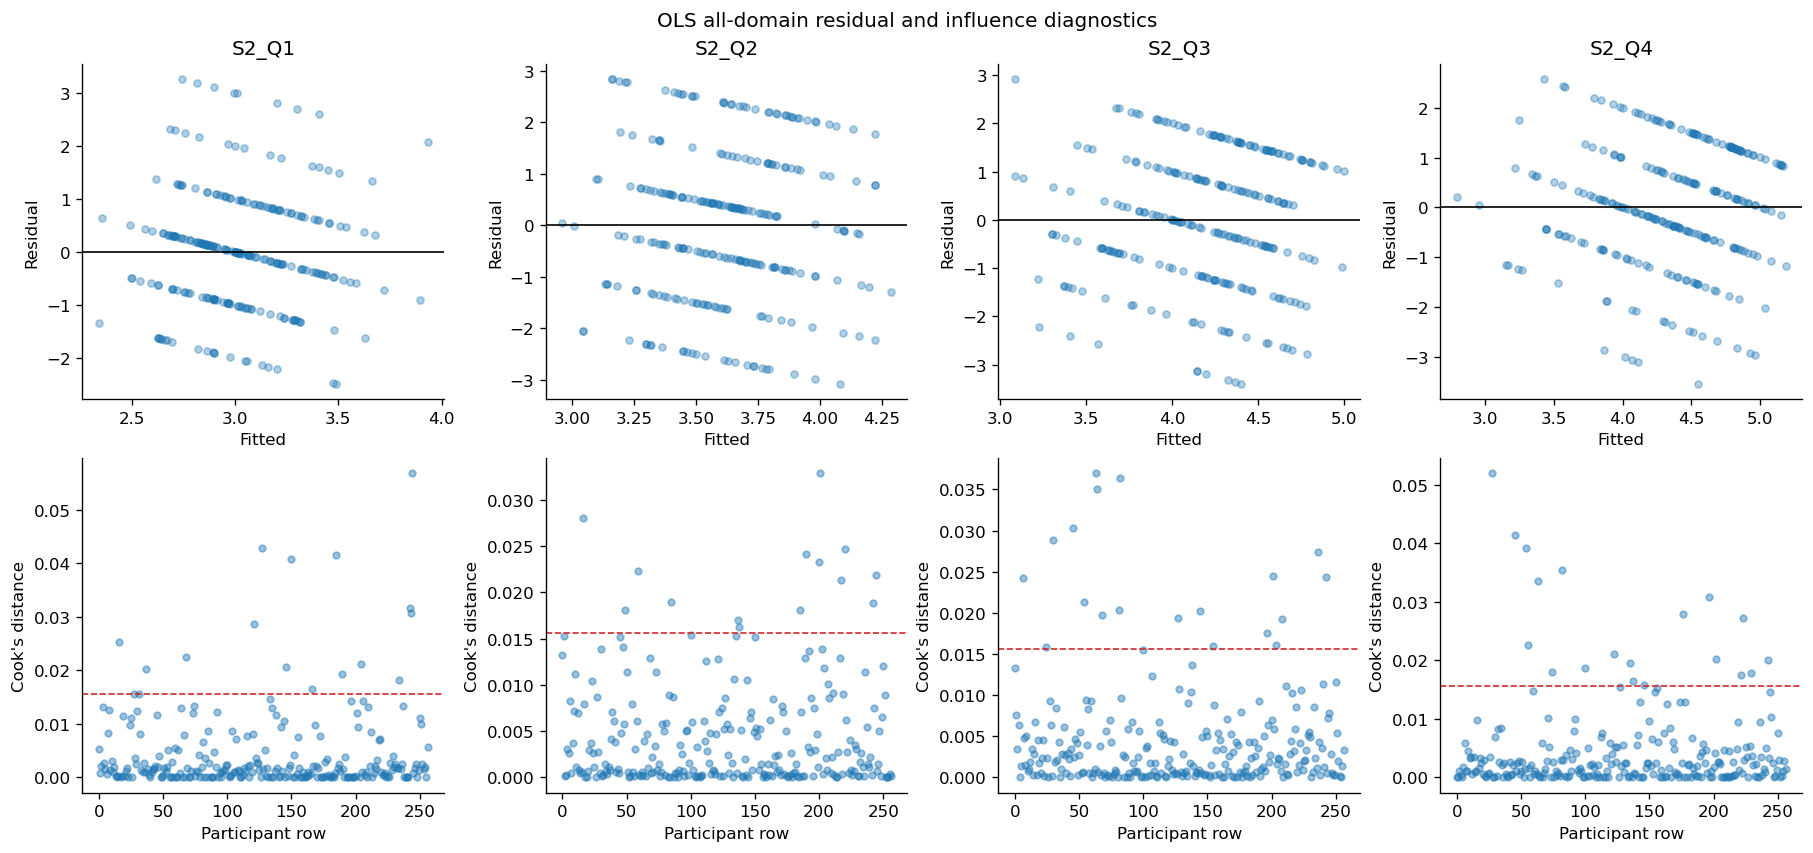

Model diagnostics:
outcome  condition_number  max_cooks_d  n_cooks_above_4_over_n  breusch_pagan_p
  S2_Q1           46.0483       0.0569                      16           0.6124
  S2_Q2           46.0483       0.0329                      14           0.4682
  S2_Q3           46.0483       0.0370                      19           0.7946
  S2_Q4           46.0483       0.0521                      19           0.3633

Variance inflation factors:
 term     VIF
const 30.7180
S1_Q1  1.0340
S1_Q2  1.0560
S1_Q3  1.1620
S1_Q4  1.1640
   G2  1.0030


In [7]:
diagnostic_rows = []
vif_rows = []
fig, axes = plt.subplots(2, 4, figsize=(15, 7), constrained_layout=True)

for index, mapping in enumerate(MAPPINGS):
    outcome = mapping['outcome']
    model = ols_models['all_domain'][outcome]['conventional']
    influence = model.get_influence()
    cooks_distance = influence.cooks_distance[0]

    diagnostic_rows.append({
        'outcome': outcome,
        'condition_number': model.condition_number,
        'max_cooks_d': cooks_distance.max(),
        'n_cooks_above_4_over_n': int((cooks_distance > 4 / len(analysis)).sum()),
        'breusch_pagan_p': sm.stats.diagnostic.het_breuschpagan(
            model.resid, model.model.exog
        )[1],
    })

    fitted = model.fittedvalues
    axes[0, index].scatter(fitted, model.resid, alpha=0.35, s=18)
    axes[0, index].axhline(0, color='black', linewidth=1)
    axes[0, index].set(title=outcome, xlabel='Fitted', ylabel='Residual')

    axes[1, index].scatter(np.arange(len(cooks_distance)), cooks_distance, alpha=0.45, s=16)
    axes[1, index].axhline(4 / len(analysis), color='tab:red', linestyle='--', linewidth=1)
    axes[1, index].set(xlabel='Participant row', ylabel="Cook's distance")

vif_exog = sm.add_constant(analysis[S1_COLS + ['G2']].astype(float))
for position, term in enumerate(vif_exog.columns):
    vif_rows.append({
        'term': term,
        'VIF': variance_inflation_factor(vif_exog.to_numpy(), position),
    })

diagnostics = pd.DataFrame(diagnostic_rows)
vif_table = pd.DataFrame(vif_rows)
fig.suptitle('OLS all-domain residual and influence diagnostics')
fig.savefig(path.join(output_folder, 'ols-diagnostics.pdf'), bbox_inches='tight')
plt.show()

print('Model diagnostics:')
print(diagnostics.round(4).to_string(index=False))
print('\nVariance inflation factors:')
print(vif_table.round(3).to_string(index=False))

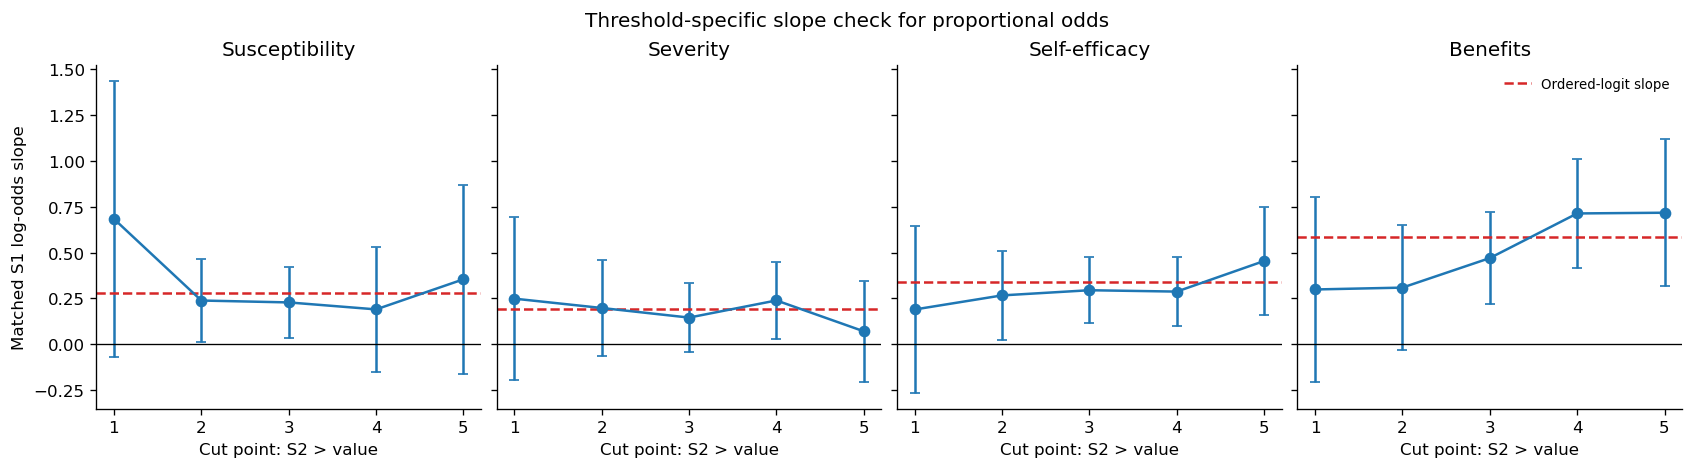

outcome         domain  threshold  events_above  events_at_or_below  estimate     se  ci_low  ci_high
  S2_Q1 Susceptibility          1           235                  22    0.6844 0.3851 -0.0704   1.4392
  S2_Q1 Susceptibility          2           179                  78    0.2389 0.1165  0.0105   0.4673
  S2_Q1 Susceptibility          3            75                 182    0.2286 0.0983  0.0360   0.4212
  S2_Q1 Susceptibility          4            23                 234    0.1905 0.1738 -0.1501   0.5312
  S2_Q1 Susceptibility          5             9                 248    0.3549 0.2635 -0.1616   0.8713
  S2_Q2       Severity          1           231                  26    0.2492 0.2271 -0.1959   0.6944
  S2_Q2       Severity          2           195                  62    0.1982 0.1324 -0.0612   0.4577
  S2_Q2       Severity          3           137                 120    0.1458 0.0959 -0.0422   0.3338
  S2_Q2       Severity          4            71                 186    0.2394 0.10

In [11]:
threshold_rows = []

for mapping in MAPPINGS:
    outcome = mapping['outcome']
    source = mapping['source']
    observed_categories = np.sort(analysis[outcome].unique()).astype(int)

    for threshold in observed_categories[:-1]:
        temporary = analysis.copy()
        temporary['above_threshold'] = (temporary[outcome] > threshold).astype(int)
        events = int(temporary['above_threshold'].sum())
        non_events = len(temporary) - events
        if min(events, non_events) < 5:
            continue

        result = smf.glm(
            f'above_threshold ~ {source} + G2',
            data=temporary,
            family=sm.families.Binomial(),
        ).fit(cov_type='HC3')

        estimate = result.params[source]
        standard_error = result.bse[source]
        threshold_rows.append({
            'outcome': outcome,
            'domain': mapping['domain'],
            'threshold': threshold,
            'events_above': events,
            'events_at_or_below': non_events,
            'estimate': estimate,
            'se': standard_error,
            'ci_low': estimate - 1.96 * standard_error,
            'ci_high': estimate + 1.96 * standard_error,
        })

threshold_slopes = pd.DataFrame(threshold_rows)
fig, axes = plt.subplots(1, 4, figsize=(14, 3.8), sharey=True, constrained_layout=True)
for axis, mapping in zip(axes, MAPPINGS):
    subset = threshold_slopes[threshold_slopes['outcome'] == mapping['outcome']]
    axis.errorbar(
        subset['threshold'],
        subset['estimate'],
        yerr=[subset['estimate'] - subset['ci_low'], subset['ci_high'] - subset['estimate']],
        fmt='o-',
        capsize=3,
        color='tab:blue',
    )
    common_slope = ordered_models['matched'][mapping['outcome']].params[mapping['source']]
    axis.axhline(common_slope, color='tab:red', linestyle='--', label='Ordered-logit slope')
    axis.axhline(0, color='black', linewidth=0.8)
    axis.set(title=mapping['domain'], xlabel='Cut point: S2 > value')
axes[0].set_ylabel('Matched S1 log-odds slope')
axes[-1].legend(frameon=False, fontsize=8)
fig.suptitle('Threshold-specific slope check for proportional odds')
fig.savefig(path.join(output_folder, 'proportional-odds-diagnostic.pdf'), bbox_inches='tight')
plt.show()

print(threshold_slopes.round(4).to_string(index=False))

In [12]:
gender_sensitivity_rows = []
gender_models = {}

for mapping in MAPPINGS:
    outcome = mapping['outcome']
    source = mapping['source']
    predictors = [source, 'G2', 'gender']
    result = fit_ordered(gender_analysis, outcome, predictors)
    gender_models[outcome] = result

    primary = ordered_models['matched'][outcome]
    gender_sensitivity_rows.append({
        'outcome': outcome,
        'domain': mapping['domain'],
        'primary_n': len(analysis),
        'primary_estimate': primary.params[source],
        'primary_se': primary.bse[source],
        'gender_adjusted_n': len(gender_analysis),
        'gender_adjusted_estimate': result.params[source],
        'gender_adjusted_se': result.bse[source],
        'gender_adjusted_p': result.pvalues[source],
        'converged': converged(result),
    })

gender_sensitivity = pd.DataFrame(gender_sensitivity_rows)
print(gender_sensitivity.round(4).to_string(index=False))

outcome         domain  primary_n  primary_estimate  primary_se  gender_adjusted_n  gender_adjusted_estimate  gender_adjusted_se  gender_adjusted_p  converged
  S2_Q1 Susceptibility        257            0.2781      0.0884                250                    0.2518              0.0888             0.0046       True
  S2_Q2       Severity        257            0.1900      0.0877                250                    0.1494              0.0903             0.0983       True
  S2_Q3  Self-efficacy        257            0.3375      0.0811                250                    0.3634              0.0834             0.0000       True
  S2_Q4       Benefits        257            0.5848      0.1078                250                    0.5606              0.1086             0.0000       True


## Coefficient plots

The first plot shows the four prespecified matched S1→S2 cumulative odds ratios. The second shows all 16 S1 paths from the domain-specific models; filled markers identify each outcome's theoretically matched S1 domain. Confidence intervals are unadjusted 95% intervals, while the accompanying tables provide Holm and Benjamini–Hochberg adjusted p-values.

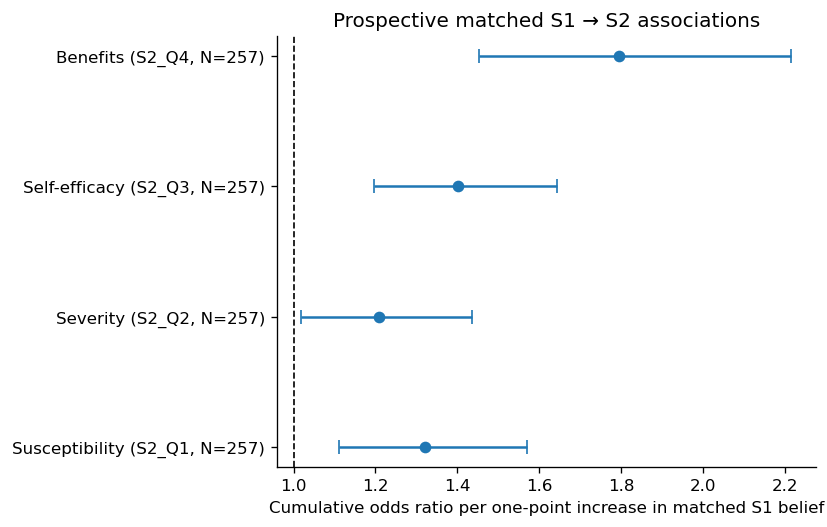

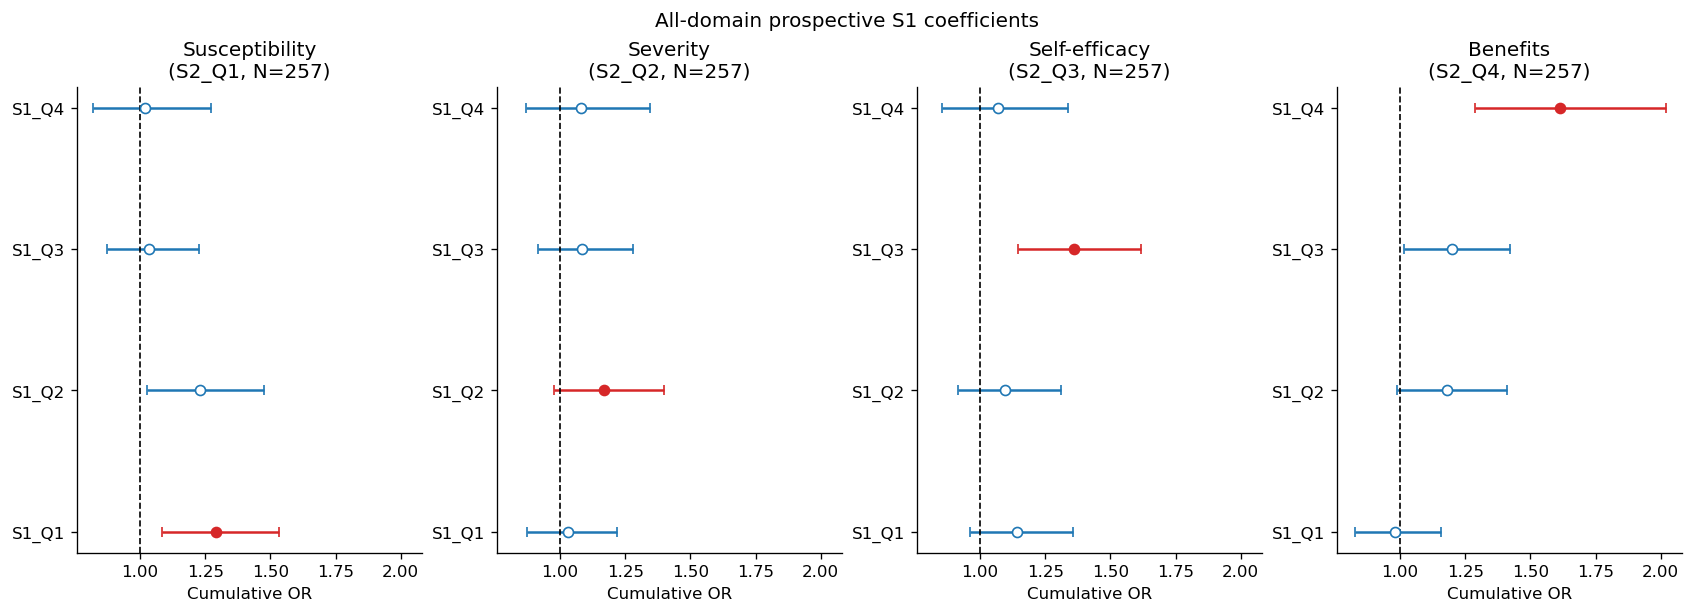

In [13]:
fig, axis = plt.subplots(figsize=(7, 4.5))
plot_data = ordered_matched.sort_values('question' if 'question' in ordered_matched else 'outcome').reset_index(drop=True)
y_positions = np.arange(len(plot_data))
axis.errorbar(
    plot_data['OR'],
    y_positions,
    xerr=[plot_data['OR'] - plot_data['OR_ci_low'], plot_data['OR_ci_high'] - plot_data['OR']],
    fmt='o',
    color='tab:blue',
    capsize=4,
)
axis.axvline(1, color='black', linestyle='--', linewidth=1)
axis.set(
    yticks=y_positions,
    yticklabels=[f"{row.domain} ({row.outcome}, N={len(analysis)})" for row in plot_data.itertuples()],
    xlabel='Cumulative odds ratio per one-point increase in matched S1 belief',
    title='Prospective matched S1 → S2 associations',
)
fig.tight_layout()
fig.savefig(path.join(output_folder, 'matched-ordered-logit-coefficients.pdf'), bbox_inches='tight')
plt.show()

fig, axes = plt.subplots(1, 4, figsize=(14, 5), sharex=True, constrained_layout=True)
for axis, mapping in zip(axes, MAPPINGS):
    subset = ordered_all_domain[
        ordered_all_domain['outcome'] == mapping['outcome']
    ].copy().reset_index(drop=True)
    y_positions = np.arange(len(subset))
    for row_position, row in subset.iterrows():
        axis.errorbar(
            row['OR'],
            row_position,
            xerr=[[row['OR'] - row['OR_ci_low']], [row['OR_ci_high'] - row['OR']]],
            fmt='o' if row['matched_domain'] else 'o',
            markerfacecolor='tab:red' if row['matched_domain'] else 'white',
            markeredgecolor='tab:red' if row['matched_domain'] else 'tab:blue',
            ecolor='tab:red' if row['matched_domain'] else 'tab:blue',
            capsize=3,
        )
    axis.axvline(1, color='black', linestyle='--', linewidth=1)
    axis.set(
        yticks=y_positions,
        yticklabels=subset['term'],
        xlabel='Cumulative OR',
        title=f"{mapping['domain']}\n({mapping['outcome']}, N={len(analysis)})",
    )
fig.suptitle('All-domain prospective S1 coefficients')
fig.savefig(path.join(output_folder, 'all-domain-ordered-logit-coefficients.pdf'), bbox_inches='tight')
plt.show()

## Export results

Exports include coefficient tables, multiplicity-adjusted results, model comparisons, diagnostics, sensitivity summaries, analysis metadata, and fitted model collections. In-sample prediction metrics are descriptive and must not be presented as out-of-sample validation.

In [14]:
tables_to_export = {
    'missingness.csv': missingness,
    'sample-retention.csv': retention,
    'ordered-matched.csv': ordered_matched,
    'ordered-all-domain.csv': ordered_all_domain,
    'ols-hc3-matched.csv': ols_matched,
    'ols-hc3-all-domain.csv': ols_all_domain,
    'model-comparison.csv': model_comparison,
    'diagnostics.csv': diagnostics,
    'vif.csv': vif_table,
    'proportional-odds-threshold-slopes.csv': threshold_slopes,
    'gender-sensitivity.csv': gender_sensitivity,
}
for filename, table in tables_to_export.items():
    table.to_csv(path.join(output_folder, filename), index=True if filename == 'missingness.csv' else False)

metadata = {
    'dataset_id': dataset_id,
    'primary_n': len(analysis),
    'gender_sensitivity_n': len(gender_analysis),
    'primary_covariates': ['G2'],
    'gender_sensitivity_covariates': ['G2', 'gender'],
    'domains': DOMAINS,
    's1_columns': S1_COLS,
    's2_columns': S2_COLS,
    'ordinal_link': 'logit',
    'multiplicity_families': {
        'matched': 'four focal matched paths',
        'all_domain': 'sixteen S1-to-S2 paths',
        'likelihood_ratio': 'four matched-versus-all-domain comparisons',
    },
}

with open(path.join(output_folder, 'analysis-metadata.pickle'), 'wb') as file:
    pickle.dump(metadata, file)
with open(path.join(output_folder, 'ordered-models.pickle'), 'wb') as file:
    pickle.dump(ordered_models, file)
with open(path.join(output_folder, 'ols-models.pickle'), 'wb') as file:
    pickle.dump(ols_models, file)
with open(path.join(output_folder, 'gender-sensitivity-models.pickle'), 'wb') as file:
    pickle.dump(gender_models, file)

print(f'Exported results to {output_folder}')
print('\nFiles:')
for filename in sorted(os.listdir(output_folder)):
    print(' ', filename)

Exported results to output/202/prospective-s1-to-s2

Files:
  all-domain-ordered-logit-coefficients.pdf
  analysis-metadata.pickle
  diagnostics.csv
  gender-sensitivity-models.pickle
  gender-sensitivity.csv
  matched-ordered-logit-coefficients.pdf
  missingness.csv
  model-comparison.csv
  ols-diagnostics.pdf
  ols-hc3-all-domain.csv
  ols-hc3-matched.csv
  ols-models.pickle
  ordered-all-domain.csv
  ordered-matched.csv
  ordered-models.pickle
  proportional-odds-diagnostic.pdf
  proportional-odds-threshold-slopes.csv
  sample-retention.csv
  vif.csv
